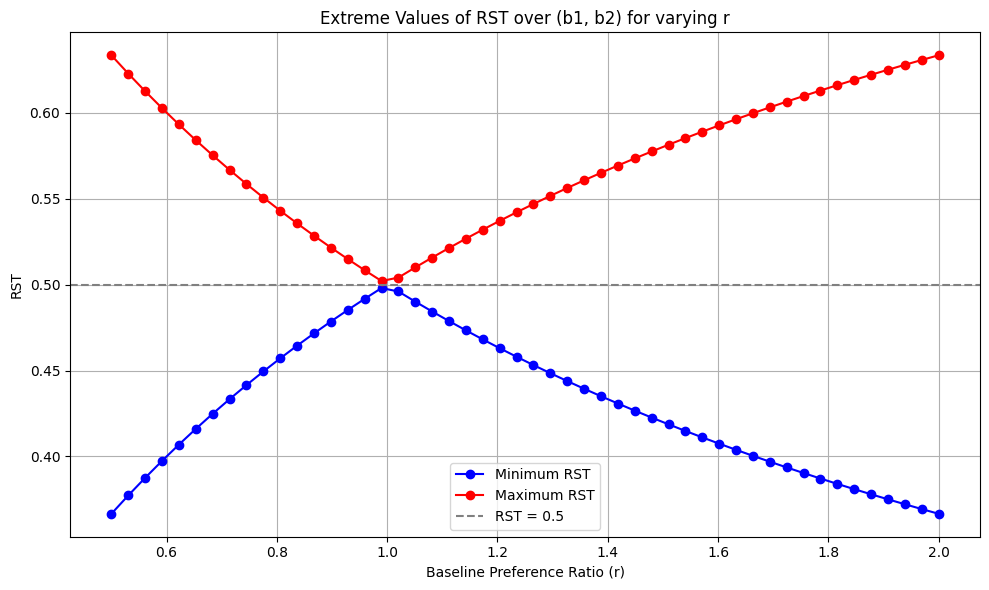

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define r values from 0.5 to 2.0
r_values = np.linspace(0.5, 2.0, 50)

# Define ranges for b1 and b2 (you can adjust these as needed)
b1_vals = np.linspace(0.05, 0.45, 100)
b2_vals = np.linspace(0.05, 0.45, 100)

min_RST = []  # will store the minimum RST for each r
max_RST = []  # will store the maximum RST for each r

# Loop over each r
for r in r_values:
    RST_list = []
    # Loop over b1 and b2
    for b1 in b1_vals:
        for b2 in b2_vals:
            # Compute RST: 
            # P_C1(A) = r * b1,  P_C1(B) = b1
            # P_C2(A) = r * b2,  P_C2(B) = b2
            # RST = (P_C1(A) + P_C2(B)) / [P_C1(A) + P_C2(B) + P_C1(B) + P_C2(A)]
            rst = (r * b1 + b2) / (r * b1 + b2 + b1 + r * b2)
            RST_list.append(rst)
    # Convert to array and record extremes
    RST_array = np.array(RST_list)
    min_RST.append(RST_array.min())
    max_RST.append(RST_array.max())

# Plot the extreme values as functions of r
plt.figure(figsize=(10, 6))
plt.plot(r_values, min_RST, label='Minimum RST', marker='o', color='blue')
plt.plot(r_values, max_RST, label='Maximum RST', marker='o', color='red')
plt.xlabel('Baseline Preference Ratio (r)')
plt.ylabel('RST')
plt.title('Extreme Values of RST over (b1, b2) for varying r')
plt.axhline(0.5, color='gray', linestyle='--', label='RST = 0.5')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


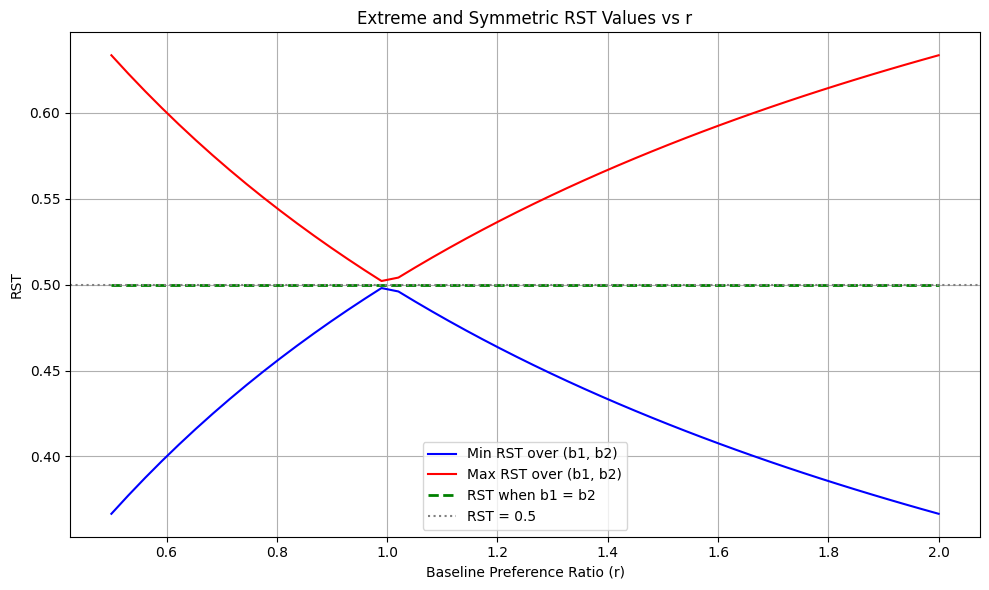

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define r values from 0.5 to 2.0
r_values = np.linspace(0.5, 2.0, 50)

# Define b1 and b2 value grid
b_vals = np.linspace(0.05, 0.45, 100)

min_RST = []  # Minimum RST for each r
max_RST = []  # Maximum RST for each r
sym_RST = []  # RST when b1 == b2

# Loop over each r
for r in r_values:
    RST_list = []

    # Loop over all combinations of b1 and b2
    for b1 in b_vals:
        for b2 in b_vals:
            rst = (r * b1 + b2) / (r * b1 + b2 + b1 + r * b2)
            RST_list.append(rst)
    
    # Also compute RST when b1 == b2
    rst_sym_values = [(r * b + b) / (r * b + b + b + r * b) for b in b_vals]
    
    min_RST.append(np.min(RST_list))
    max_RST.append(np.max(RST_list))
    sym_RST.append(np.mean(rst_sym_values))  # All equal since b1 = b2

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(r_values, min_RST, label='Min RST over (b1, b2)', color='blue')
plt.plot(r_values, max_RST, label='Max RST over (b1, b2)', color='red')
plt.plot(r_values, sym_RST, label='RST when b1 = b2', color='green', linewidth=2, linestyle='--')

plt.axhline(0.5, color='gray', linestyle=':', label='RST = 0.5')
plt.xlabel('Baseline Preference Ratio (r)')
plt.ylabel('RST')
plt.title('Extreme and Symmetric RST Values vs r')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('RST_vs_r_plot.png', dpi=300, bbox_inches='tight')
plt.show()


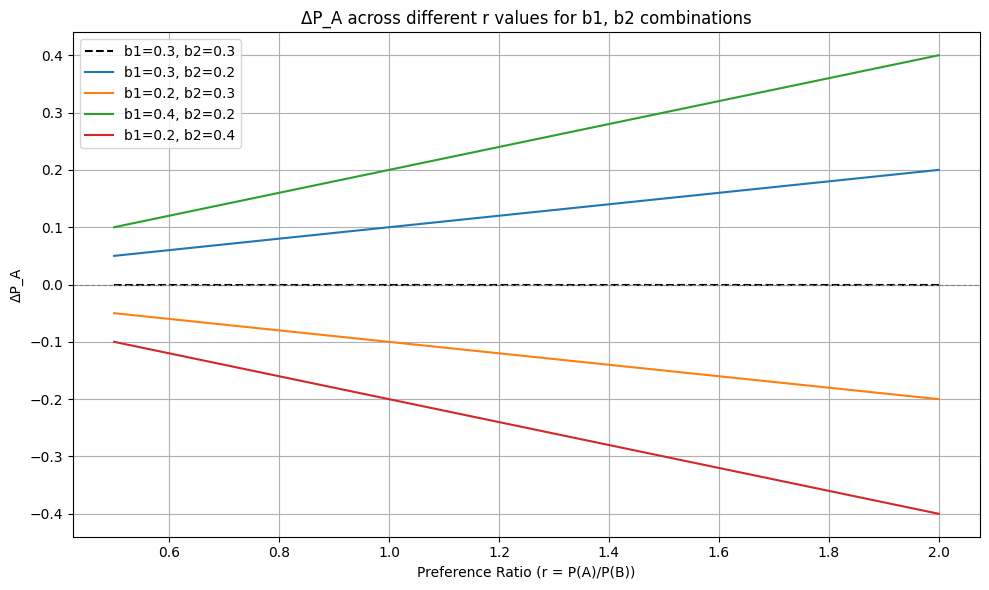

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define range for r
r_vals = np.linspace(0.5, 2.0, 300)

# Define b1 and b2 combinations
b_pairs = [(0.3, 0.3), (0.3, 0.2), (0.2, 0.3), (0.4, 0.2), (0.2, 0.4)]

plt.figure(figsize=(10, 6))

for b1, b2 in b_pairs:
    delta_P_A = r_vals * (b1 - b2)
    label = f"b1={b1}, b2={b2}"
    color = 'black' if b1 == b2 else None
    linestyle = '--' if b1 == b2 else '-'
    
    plt.plot(r_vals, delta_P_A, label=label, color=color, linestyle=linestyle)

# Add a zero reference line
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel("Preference Ratio (r = P(A)/P(B))")
plt.ylabel("ΔP_A")
plt.title("ΔP_A across different r values for b1, b2 combinations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


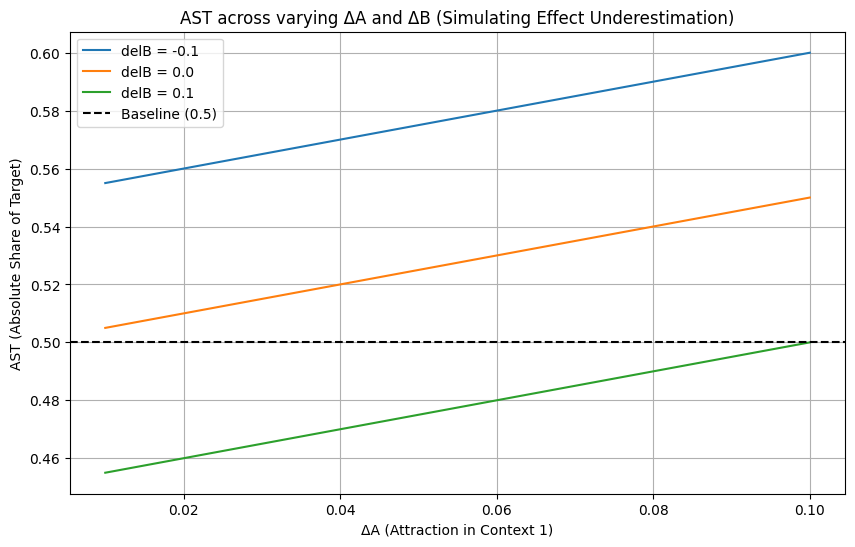

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define baseline choice probabilities
p0_A = 0.5
p0_B = 0.5

# Range of delA (positive attraction effect in context 1)
delA_values = np.linspace(0.01, 0.1, 50)

# Values of delB (effects in context 2): negative, zero, positive
delB_values = [-0.1, 0.0, 0.1]

# Prepare plot
plt.figure(figsize=(10, 6))

for delB in delB_values:
    ASTs = []
    for delA in delA_values:
        # Compute choice shares in each context
        p1_A = p0_A + delA
        p1_B = p0_B - delA  # assuming symmetric effect for simplicity
        p2_A = p0_A + delB
        p2_B = p0_B - delB

        # Calculate AST
        AST = 0.5 * (p1_A + p2_B)
        ASTs.append(AST)
    label = f"delB = {delB}"
    plt.plot(delA_values, np.array(ASTs), label=label)

plt.axhline(0.5, color='k', linestyle='--', label='Baseline (0.5)')
plt.xlabel('ΔA (Attraction in Context 1)')
plt.ylabel('AST (Absolute Share of Target)')
plt.title('AST across varying ΔA and ΔB (Simulating Effect Underestimation)')
plt.legend()
plt.grid(True)
plt.show()


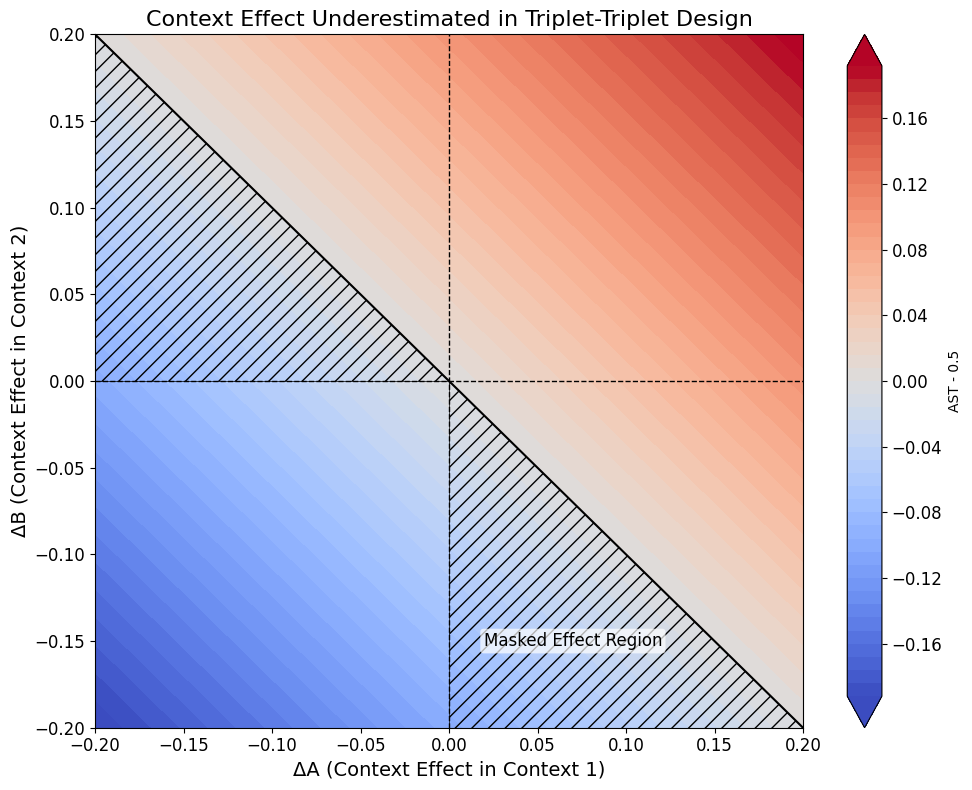

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Simulation parameters
delA_values = np.linspace(-0.2, 0.2, 100)
delB_values = np.linspace(-0.2, 0.2, 100)

# Calculate AST effect
AST = 0.5 * (1 + delA_values[:, np.newaxis] + delB_values)
effect = AST - 0.5

# Plot heatmap
plt.figure(figsize=(10, 8))
contour = plt.contourf(delA_values, delB_values, effect.T, 
                       levels=50, cmap='coolwarm', extend='both')
cbar = plt.colorbar(contour, label='AST - 0.5')
cbar.ax.tick_params(labelsize=12)

# Reference lines
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.plot(delA_values, -delA_values, 'k-', label='ΔA = -ΔB (Total Cancellation)')

# Draw polygon with hatching below ΔA = -ΔB
polygon_coords = [
    [-0.2, 0.2],    # bottom left corner
    [-0.2, 0],     # top left corner
    [0,0],
    [0,-0.2],
    [0.2, -0.2]     # bottom right corner
    
]

polygon = Polygon(polygon_coords, closed=True,
                  facecolor='none', edgecolor='black',
                  hatch='//', linewidth=0.5)
plt.gca().add_patch(polygon)

# # Add label inside the hatched region
plt.text(0.07, -0.15, 'Masked Effect Region', fontsize=12, rotation=0,
         ha='center', va='center',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

# Labels and title
plt.xlabel('ΔA (Context Effect in Context 1)', fontsize=14)
plt.ylabel('ΔB (Context Effect in Context 2)', fontsize=14)
plt.title('Context Effect Underestimated in Triplet-Triplet Design', fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig('AST_heatmap_polygon_pattern.png', dpi=600, bbox_inches='tight')
plt.show()